<div class="alert alert-block alert-success">
<b>Comentario general del revisor</b> <a class="tocSkip"></a><br />
Status del proyecto: <b>Aprobado</b>
</div>


¡Hola!<br />
Soy **Francisco Cortés**, estoy contento de revisar tu proyecto y ser parte de tu proceso de aprendizaje.
A lo largo del texto, haré algunas observaciones sobre mejoras en el código y también haré comentarios sobre tus percepciones sobre el tema. Si existe algún error en el código, no te preocupes, estoy aquí para ayudarte a mejorarlo, en la primera iteración te lo señalaré para que tengas la oportunidad de corregirlo, pero si aún no encuentras una solución para esta tarea, te daré una pista más precisa en la próxima iteración y también algunos ejemplos prácticos. Estaré abierto a retroalimentación y discusiones sobre el tema.<br />
Encontrarás mis comentarios a continuación - **por favor no los muevas, modifiques o borres**.
Revisaré cuidadosamente tu código para comprobar que se han cumplido con los requisitos y te proporcionaré mis comentarios en cajas verdes, amarillas o rojas como esta:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si la ejecución fue perfecta succesfully.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existe alguna recomendación para que tu código mejore.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existen correcciones necesarias para cumplir con los requisitos. El trabajo no puede ser aceptado si hay alguna caja roja.
</div>

Puedes responderme de la siguiente manera:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante.</b> <a class="tocSkip"></a>
</div>


 #¡Llena ese carrito!

# Introducción

Instacart es una plataforma de entregas de comestibles donde la clientela puede registrar un pedido y hacer que se lo entreguen, similar a Uber Eats y Door Dash.
El conjunto de datos que te hemos proporcionado tiene modificaciones del original. Redujimos el tamaño del conjunto para que tus cálculos se hicieran más rápido e introdujimos valores ausentes y duplicados. Tuvimos cuidado de conservar las distribuciones de los datos originales cuando hicimos los cambios.

Debes completar tres pasos. Para cada uno de ellos, escribe una breve introducción que refleje con claridad cómo pretendes resolver cada paso, y escribe párrafos explicatorios que justifiquen tus decisiones al tiempo que avanzas en tu solución.  También escribe una conclusión que resuma tus hallazgos y elecciones.


## Diccionario de datos

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos. A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

# Paso 1. Descripción de los datos

Lee los archivos de datos (`/datasets/instacart_orders.csv`, `/datasets/products.csv`, `/datasets/aisles.csv`, `/datasets/departments.csv` y `/datasets/order_products.csv`) con `pd.read_csv()` usando los parámetros adecuados para leer los datos correctamente. Verifica la información para cada DataFrame creado.


## Plan de solución

Escribe aquí tu plan de solución para el Paso 1. Descripción de los datos.
Para comprender la estructura y calidad del conjunto de datos de Instacart, seguimos estos pasos:

-Importar librerías necesarias usando pandas para la manipulación de datos.
-Leer los conjuntos de datos acragando los archivos CSV en DataFrames usando pd.read_csv().
-Explorar la información general de los DataFrames através de .info() con la finalidad de conocer el tipo de datos, cantidad de valores nulos y el tamaño de cada tabla.

Visualizar una muestra de los datos: Usaremos .head() para obtener una vista preliminar de las primeras filas.

Verificar valores únicos y nulos: Usaremos .isnull().sum() para detectar valores faltantes y .duplicated().sum() para identificar registros duplicados.

Identificar relaciones clave entre tablas: Revisaremos columnas de identificadores comunes para futuras uniones entre tablas.




In [1]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# leer conjuntos de datos en los DataFrames
orders = pd.read_csv("/datasets/instacart_orders.csv", sep=';')
products = pd.read_csv("/datasets/products.csv", sep=';')
aisles = pd.read_csv("/datasets/aisles.csv", sep=';')
departments = pd.read_csv("/datasets/departments.csv", sep=';')
order_products = pd.read_csv("/datasets/order_products.csv", sep=';')

In [3]:
# mostrar información del DataFrame
print(orders.info())
print(orders.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB
None
   order_id  user_id  order_number  order_dow  order_hour_of_day  \
0   1515936   183418            11          6                 13   
1   1690866   163593             5          5                 12   
2   1454967    39980             4          5                 19   
3   1768857    82516            56          0                 20   
4   3007858   196724             2          4                 

In [4]:
# mostrar información del DataFrame
print(products.info())
print(products.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
None
   product_id                                       product_name  aisle_id  \
0           1                         Chocolate Sandwich Cookies        61   
1           2                                   All-Seasons Salt       104   
2           3               Robust Golden Unsweetened Oolong Tea        94   
3           4  Smart Ones Classic Favorites Mini Rigatoni Wit...        38   
4           5                          Green Chile Anytime Sauce         5   

   department_id  
0             19  
1             13  
2              7  
3              1  
4             1

In [5]:
# mostrar información del DataFrame
print(aisles.info())
print(aisles.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB
None
   aisle_id                       aisle
0         1       prepared soups salads
1         2           specialty cheeses
2         3         energy granola bars
3         4               instant foods
4         5  marinades meat preparation


In [6]:
# mostrar información del DataFrame
print(departments.info())
print(departments.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 464.0+ bytes
None
   department_id department
0              1     frozen
1              2      other
2              3     bakery
3              4    produce
4              5    alcohol


In [7]:
# mostrar información del DataFrame
print(order_products.info())
print(order_products.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype  
---  ------             -----  
 0   order_id           int64  
 1   product_id         int64  
 2   add_to_cart_order  float64
 3   reordered          int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB
None
   order_id  product_id  add_to_cart_order  reordered
0   2141543       11440               17.0          0
1    567889        1560                1.0          1
2   2261212       26683                1.0          1
3    491251        8670               35.0          1
4   2571142        1940                5.0          1


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!<br/>
Buena manera de leer los datos y buenas observaciones iniciales.<br/>
    
La razón del por que no te aparecen todos los valores del dataframe `df_order_products` es porque es contiene mucha información y pandas trata de optimizar esto al no mostrar los resultados, pero le podemos indicar que lo haga de cualquier manera utilizando el siguiente argumento:
    
```
order_products.info(show_counts=True)    
```    
</div>


## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 1. Descripción de los datos.
- No hay datos de decimales con ',', solo hay puntos '.'.
- La mayoría de las columnas contienen datos numéricos (int64 o float64), excepto aquellas con nombres de productos, pasillos y departamentos, que son object.
- Se debe revisar si los identificadores (order_id, product_id, aisle_id, etc.) están correctamente definidos como enteros.
- Es necesário verificar si existen filas duplicadas en los conjuntos de datos, especialmente en products y order_products, ya que podrían afectar los análisis.
- Deberemos tratar los valores nulos (rellenar, eliminar o analizar su impacto).Eliminar duplicados si es necesario.

# Paso 2. Preprocesamiento de los datos

Preprocesa los datos de la siguiente manera:

- Verifica y corrige los tipos de datos (por ejemplo, asegúrate de que las columnas de ID sean números enteros).
- Identifica y completa los valores ausentes.
- Identifica y elimina los valores duplicados.

Asegúrate de explicar qué tipos de valores ausentes y duplicados encontraste, cómo los completaste o eliminaste y por qué usaste esos métodos. ¿Por qué crees que estos valores ausentes y duplicados pueden haber estado presentes en el conjunto de datos?

## Plan de solución

Escribe aquí tu plan para el Paso 2. Preprocesamiento de los datos.
- En primer lugar verificamos se hay valores nulos en cada DataFrame, de esta forma sabremos quales deberemos tratar.
- Encontrados cuales son los datos nulos o ausentes y de acuerdo con los datos, podremos saber si podemos llenarlos com la media aritmética o mediana. 
- Después verificar los duplicados (duplicated()) e eliminarlos (rop_duplicates())

In [8]:
# Verificar valores nulos en cada DataFrame
print("Valores nulos en orders:")
print(orders.isnull().sum())

print("Valores nulos en products:")
print(products.isnull().sum())

print("Valores nulos en aisles:")
print(aisles.isnull().sum())

print("Valores nulos en departments:")
print(departments.isnull().sum())

print("Valores nulos en order_products:")
print(order_products.isnull().sum())

Valores nulos en orders:
order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28819
dtype: int64
Valores nulos en products:
product_id          0
product_name     1258
aisle_id            0
department_id       0
dtype: int64
Valores nulos en aisles:
aisle_id    0
aisle       0
dtype: int64
Valores nulos en departments:
department_id    0
department       0
dtype: int64
Valores nulos en order_products:
order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64


In [9]:
# Rellenar valores nulos en 'days_since_prior_order' con 0 (primer pedido)
orders["days_since_prior_order"] = orders["days_since_prior_order"].fillna(0)

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Cuidado!<br/>

No es correcto haber reemplazado los valores ausentes en esta columna, en este caso todos los primeros clientes no tienen algun valor en esta columna porque solo han hecho una compra, pero hay clientes que han hecho más de una compra en un solo día por lo que estos son los que verdaderamente tienen 0 en la columna
</div>


## Encuentra y elimina los valores duplicados (y describe cómo tomaste tus decisiones).

### `orders` data frame

In [10]:
# Revisa si hay pedidos duplicados
duplicated_orders = orders[orders.duplicated()]
print(duplicated_orders)

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
145574    794638    50898            24          3                  2   
223105   2160484   107525            16          3                  2   
230807   1918001   188546            14          3                  2   
266232   1782114   106752             1          3                  2   
273805   1112182   202304            84          3                  2   
284038   2845099    31189            11          3                  2   
311713   1021560    53767             3          3                  2   
321100    408114    68324             4          3                  2   
323900   1919531   191501            32          3                  2   
345917   2232988    82565             1          3                  2   
371905    391768    57671            19          3                  2   
394347    467134    63189            21          3                  2   
411408   1286742   183220            48          3 

In [11]:
days_since_prior_order_avg = orders['days_since_prior_order'].mean()
print("Mean days_since_prior_order:", days_since_prior_order_avg)

orders['days_since_prior_order'] = orders['days_since_prior_order'].fillna(days_since_prior_order_avg)
print(orders['days_since_prior_order'])

Mean days_since_prior_order: 10.43376892353753
0         30.0
1          9.0
2          2.0
3         10.0
4         17.0
          ... 
478962     7.0
478963     6.0
478964     6.0
478965     8.0
478966    15.0
Name: days_since_prior_order, Length: 478967, dtype: float64


¿Tienes líneas duplicadas? Si sí, ¿qué tienen en común?
-Los valores de "order_dow" (día de la semana del pedido) y "order_hour_of_day" (hora del pedido) son los mismos
-Cada fila es un pedido que ya apareció antes
- Algunas filas tienen valores NaN en "days_since_prior_orders", por lo que se les substituyó por la média aritmética. 
- También se pasaron a enteros

In [12]:
# Basándote en tus hallazgos,
# Verifica todos los pedidos que se hicieron el miércoles a las 2:00 a.m.
wednesday_orders = orders[(orders['order_dow']==3) & (orders['order_hour_of_day']==2)]
print(wednesday_orders)

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
4838     2766110   162084            41          3                  2   
5156     2190225   138285            18          3                  2   
15506     553049    58599            13          3                  2   
18420     382357   120200            19          3                  2   
24691     690242    77357             2          3                  2   
...          ...      ...           ...        ...                ...   
457013   3384021    14881             6          3                  2   
458816    910166   164782            18          3                  2   
459635   1680532   106435             6          3                  2   
468324    222962    54979            59          3                  2   
477526   2592344    46860            38          3                  2   

        days_since_prior_order  
4838                      16.0  
5156                      11.0  
15506                   

¿Qué sugiere este resultado?
- order_number varían, y hay usuarios que han realizado varias compras antes.
- haya varios registros sugiere que algunos clientes realizan compras en horarios no convencionales.
- Algunos tienen pedidos recientes (days_since_prior_order de solo 3 o 4 días), lo que sugiere que pueden ser clientes recurrentes.
- Otros esperan más tiempo (16, 30 días), lo que sugiere diferentes hábitos de consumo.

In [13]:
# Elimina los pedidos duplicados
orders = orders.drop_duplicates()

In [14]:
# Vuelve a verificar si hay filas duplicadas
duplicated_orders = orders[orders.duplicated()]
print(duplicated_orders)

Empty DataFrame
Columns: [order_id, user_id, order_number, order_dow, order_hour_of_day, days_since_prior_order]
Index: []


In [15]:
# Vuelve a verificar únicamente si hay IDs duplicados de pedidos
print(orders['order_id'].duplicated().sum())

0


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>
Los duplicados fueron eliminados correctamente
</div>


Describe brevemente tus hallazgos y lo que hiciste con ellos
- Se revisó si había order_id duplicados, ya que cada pedido debe tener un ID único.
- El resultado (0) indica que todos los pedidos tienen identificadores únicos, lo que significa que no hay errores en la asignación de IDs.
- Esto sugiere que la presencia de duplicados iniciales pudo haber sido un error en la recopilación o procesamiento de datos. Ahora el conjunto de datos está limpio y listo para análisis.

### `products` data frame 


In [16]:
# Verifica si hay filas totalmente duplicadas
print(products.duplicated().sum())

0


In [17]:
# Revisa únicamente si hay ID de departamentos duplicados
print(products['department_id'].duplicated().sum())

49673


In [18]:
# Revisa únicamente si hay nombres duplicados de productos (convierte los nombres a letras mayúsculas para compararlos mejor)
order_products['product_name'] = products['product_name'].str.upper()
print(products['product_name'].duplicated().sum())

1257


In [19]:
# Revisa si hay nombres duplicados de productos no faltantes
duplicados = products['product_name'].dropna()  # Eliminar valores NaN
duplicados = duplicados[duplicados.duplicated(keep=False)]  # Filtrar solo duplicados
print(duplicados)




Series([], Name: product_name, dtype: object)


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>
Los datos han sido revisados apropiadamente
</div>


Describe brevemente tus hallazgos y lo que hiciste con ellos.
- 

### `departments` data frame

In [20]:
# Revisa si hay filas totalmente duplicadas
departments = departments.drop_duplicates()

In [21]:
# Revisa únicamente si hay IDs duplicadas de productos
print(departments['department_id'].duplicated().sum())

0


Describe brevemente tus hallazgos y lo que hiciste con ellos.
- Se usó drop_duplicates() en el DataFrame departments para eliminar cualquier fila completamente duplicada. Esto garantiza que no haya departamentos repetidos en la base de datos.
- Se verificó si había department_id duplicados, ya que cada departamento debe tener un identificador único. El resultado (0) indica que todos los departamentos tienen un ID único, lo que confirma la integridad de los datos.
- No se encontraron valores duplicados en department_id, lo que significa que la información de los departamentos estaba correctamente estructurada. La limpieza de filas repetidas asegura que los análisis no se vean afectados por registros redundantes.

### `aisles` data frame

In [22]:
# Revisa si hay filas totalmente duplicadas
aisles = aisles.drop_duplicates()

In [23]:
# Revisa únicamente si hay IDs duplicadas de pasillos
print(aisles['aisle_id'].duplicated().sum())

0


Describe brevemente tus hallazgos y lo que hiciste con ellos.
- Se utilizó una abordaje similar al item anterior y por lo tanto: No se encontraron valores duplicados en aisle_id, lo que implica que los datos sobre los pasillos son correctos y no hay redundancia en los identificadores. La limpieza de filas repetidas asegura que los análisis se realicen con datos únicos y fiables.

### `order_products` data frame

In [24]:
# Revisa si hay filas totalmente duplicadas
order_products = order_products.drop_duplicates()

In [25]:
# Vuelve a verificar si hay cualquier otro duplicado engañoso
print(order_products.duplicated(subset=['order_id', 'product_id']).sum())

0


Describe brevemente tus hallazgos y lo que hiciste con ellos.
- En semejanza a los anteriores itens, se hizo aqui también el mismo análisis. No se encontraron duplicados en los pares order_id y product_id, lo que implica que los productos en cada pedido están correctamente registrados y no existen entradas redundantes para un mismo producto en un pedido. Esto asegura que la base de datos de artículos pedidos es precisa y lista para el análisis.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!<br/>
Estos últimos dataframes no cuentan con filas totalmente duplicadas.

</div


## Encuentra y elimina los valores ausentes

Al trabajar con valores duplicados, pudimos observar que también nos falta investigar valores ausentes:

* La columna `'product_name'` de la tabla products.
* La columna `'days_since_prior_order'` de la tabla orders.
* La columna `'add_to_cart_order'` de la tabla order_productos.

### `products` data frame

In [26]:
# Encuentra los valores ausentes en la columna 'product_name'
print(products['product_name'].isnull().sum())
products['product_name'].fillna('Unknown', inplace=True)

1258


<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Cuidado!<br/>

Reemplazaste los valores sin haber hecho una revisión inicial

</div


Describe brevemente cuáles son tus hallazgos.
- Al analizar la columna product_name en la tabla products, encontramos que había 1,258 valores nulos. Para corregir este problema, reemplazamos estos valores ausentes con 'Unknown', asegurando que cada producto tenga un nombre asignado.
- La posible razón para los datos incompletos en la fuente original es que algunos productos no tuvieran un nombre registrado al momento de la recopilación.
- Errores en la integración de datos: Al combinar diferentes bases de datos, algunos registros pueden haber perdido información clave.

In [27]:
#  ¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100?

# Filtrar productos con valores nulos en 'product_name' y comprobar si están relacionados con el pasillo ID 100
missing_product_names = products[products['product_name'].isnull()]
aisle_100_missing = missing_product_names[missing_product_names['aisle_id'] == 100]
# Ver el resultado
print(aisle_100_missing)

Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []


Describe brevemente cuáles son tus hallazgos.
- Al filtrar los productos con valores nulos en la columna product_name, encontramos 1,258 registros sin nombre. Luego, verificamos si estos productos estaban relacionados con el pasillo con ID 100, pero el resultado mostró 0 coincidencias.
- Los productos sin nombre no están relacionados con el pasillo ID 100. Esto descarta la hipótesis de que la ausencia de nombres estuviera concentrada en este pasillo en particular. Debemos explorar otras posibles razones, como si estos productos pertenecen a un departamento específico (por ejemplo, ID 21) o si el problema se debe a errores de integración en los datos.

In [28]:
# ¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?
# Filtrar los productos con nombres ausentes que pertenecen al departamento 21
missing_names_in_dept_21 = missing_product_names[missing_product_names['department_id'] == 21]
print(missing_names_in_dept_21.shape[0])  # Número de productos con nombre ausente en el departamento 21

0


Describe brevemente cuáles son tus hallazgos.
- Al verificar si los productos con nombres ausentes estaban relacionados con el departamento con ID 21, encontramos que ninguno de los 1,258 productos sin nombre pertenece a este departamento (0 coincidencias).
- Los productos con nombres ausentes no están vinculados exclusivamente ni al pasillo con ID 100 ni al departamento con ID 21.

In [29]:
# Usa las tablas department y aisle para revisar los datos del pasillo con ID 100 y el departamento con ID 21.
# Filtrar productos que están en ambos, pasillo 100 y departamento 21
aisle_100_dept_21_products = products[(products['aisle_id'] == 100) & (products['department_id'] == 21)]

# Mostrar los resultados
print(aisle_100_dept_21_products.shape[0])  # Cantidad de productos en ambos
print(aisle_100_dept_21_products.head())    # Muestra algunos registros

1258
     product_id product_name  aisle_id  department_id
37           38      Unknown       100             21
71           72      Unknown       100             21
109         110      Unknown       100             21
296         297      Unknown       100             21
416         417      Unknown       100             21


Describe brevemente cuáles son tus hallazgos.
- Todos los 1,258 productos sin nombre pertenecen al pasillo con ID 100 y al departamento con ID 21.
- El problema parece estar centrado en una categoría específica de productos, lo que sugiere que puede haber un error en la base de datos que afectó exclusivamente a este pasillo y departamento.
- Estos productos podrían haber sido agregados sin nombres en el sistema.

In [30]:
# Completa los nombres de productos ausentes con 'Unknown'
# Reemplazar valores nulos en la columna 'product_name' con 'Unknown'
products['product_name'].fillna('Unknown', inplace=True)

# Verificar si aún quedan valores nulos
print(products['product_name'].isnull().sum())  # Debería imprimir 0

0


Describe brevemente tus hallazgos y lo que hiciste con ellos.
- Se identificaron 1,258 productos con nombres ausentes (NaN) en la columna product_name.
- Se reemplazaron estos valores nulos con "Unknown" para asegurar que no haya datos faltantes en la columna.
- Después de la sustitución, verificamos que no queden valores nulos,

### `orders` data frame

In [31]:
# Encuentra los valores ausentes
print(orders['days_since_prior_order'].isnull().sum())
orders['days_since_prior_order'].fillna(orders['days_since_prior_order'].median(), inplace=True)

0


In [32]:
# ¿Hay algún valor ausente que no sea el primer pedido del cliente?

# Filtrar los pedidos donde 'days_since_prior_order' es nulo
missing_days_orders = orders[orders['days_since_prior_order'].isnull()]

# Verificar si todos los pedidos con valores nulos en 'days_since_prior_order' son los primeros pedidos
print(missing_days_orders['order_number'].unique())  # Debería imprimir solo [1]

[]


Describe brevemente tus hallazgos y lo que hiciste con ellos.
- El resultado obtenido es una lista vacía [], lo que indica que no hay registros con valores nulos en la columna days_since_prior_order. Esto confirma que todos los valores ausentes fueron imputados correctamente con la mediana, y ahora la columna está completamente llena.

### `order_products` data frame

In [33]:
# Encuentra los valores ausentes
print(order_products['add_to_cart_order'].isnull().sum())


836


In [34]:
# ¿Cuáles son los valores mínimos y máximos en esta columna?
print(order_products['add_to_cart_order'].min() )
print(order_products['add_to_cart_order'].max() )

1.0
64.0


Describe brevemente cuáles son tus hallazgos.
- Hay 836 valores nulos en la columna add_to_cart_order, lo que significa que en algunos registros no se registró en qué posición fue añadido el producto al carrito.
- Mínimo=1 , Indica que algunos productos fueron los primeros en ser añadidos al carrito.
- Máximo=64, Indica que algunos carritos tuvieron hasta 64 productos añadidos en diferentes posiciones.

In [35]:
order_products.loc[order_products['add_to_cart_order'].isnull(), "order_id"]

737        2449164
9926       1968313
14394      2926893
16418      1717990
30114      1959075
            ...   
4505662    1800005
4511400    1633337
4517562     404157
4534112    1673227
4535739    1832957
Name: order_id, Length: 836, dtype: int64

In [36]:
# Guarda todas las IDs de pedidos que tengan un valor ausente en 'add_to_cart_order'

missing_add_to_cart_orders= order_products.loc[order_products['add_to_cart_order'].isnull(), "order_id"]
print(f"Se encontraron {len(missing_add_to_cart_orders)} pedidos con valores ausentes en 'add_to_cart_order'.")

Se encontraron 836 pedidos con valores ausentes en 'add_to_cart_order'.


In [37]:
# ¿Todos los pedidos con valores ausentes tienen más de 64 productos?
# Agrupa todos los pedidos con datos ausentes por su ID de pedido.
order_products.loc[order_products['add_to_cart_order'].isnull()].groupby("order_id")["product_id"].size()
# Cuenta el número de 'product_id' en cada pedido y revisa el valor mínimo del conteo.
order_products.loc[order_products['add_to_cart_order'].isnull()].groupby("order_id")["product_id"].size().min()

1

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Cuidado!<br/>
    
El valor minimo para ordenes que tienen valores nulos es `65`, te dejo el código en la celda de abajo
</div>


In [38]:
# Código del revisor
order_products[order_products['order_id'].isin(missing_add_to_cart_orders)].groupby('order_id')['product_id'].count().min()

65

Describe brevemente cuáles son tus hallazgos.
- Pedidos con valores ausentes: Se han identificado pedidos en los que add_to_cart_order es nulo.
- El resultado de min() es 1, lo que significa que al menos un pedido con datos faltantes tiene solo un producto.

In [39]:
# Remplaza los valores ausentes en la columna 'add_to_cart? con 999 y convierte la columna al tipo entero.

# Reemplazar valores nulos en 'add_to_cart_order' con 999
order_products['add_to_cart_order'].fillna(999, inplace=True)

# Convertir la columna a tipo entero
order_products['add_to_cart_order'] = order_products['add_to_cart_order'].astype(int)

# Verificar que ya no haya valores nulos
print("Valores nulos en 'add_to_cart_order':", order_products['add_to_cart_order'].isnull().sum())  # Debería ser 0

Valores nulos en 'add_to_cart_order': 0


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>
La manera de encontrar los valores ausentes y reemplazarlos con un valor generico es correcta
</div>


Describe brevemente tus hallazgos y lo que hiciste con ellos.
- Después de la limpieza, la cantidad de valores nulos en la columna es 0, lo que indica que el proceso fue lo esperado.
- Ahora, la columna 'add_to_cart_order' está completa y lista para su uso sin problemas de valores faltantes o inconsistencias de tipo de dato.
- La columna 'add_to_cart_order' almacena el número de orden en el que se añadió un producto al carrito y según los datos, los valores reales oscilan entre 1 y 64. Usar 999 evita confusión con valores reales, permitiendo identificar fácilmente los datos faltantes. El 999 es solo un valor temporalmente asignado para que los datos sean más manejables y coherentes, sin afectar el análisis posterior.

## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 2. Preprocesamiento de los datos
- El preprocesamiento de datos garantiza que los análisis y modelos sean más precisos y confiables. Lidiar con tipos de datos incorrectos, valores ausentes y duplicados ayuda a evitar errores en cálculos y visualizaciones, mejorando la interpretación de los datos.

# Paso 3. Análisis de los datos

Una vez los datos estén procesados y listos, haz el siguiente análisis:

# [A] Fácil (deben completarse todos para aprobar)

1. Verifica que los valores en las columnas `'order_hour_of_day'` y `'order_dow'` en la tabla orders sean razonables (es decir, `'order_hour_of_day'` oscile entre 0 y 23 y `'order_dow'` oscile entre 0 y 6).
2. Crea un gráfico que muestre el número de personas que hacen pedidos dependiendo de la hora del día.
3. Crea un gráfico que muestre qué día de la semana la gente hace sus compras.
4. Crea un gráfico que muestre el tiempo que la gente espera hasta hacer su siguiente pedido, y comenta sobre los valores mínimos y máximos.

### [A1] Verifica que los valores sean sensibles

In [40]:
# Verificar los valores únicos en 'order_hour_of_day' y 'order_dow'
print("Valores únicos en 'order_hour_of_day':", orders['order_hour_of_day'].unique())
print("Valores únicos en 'order_dow':", orders['order_dow'].unique())

Valores únicos en 'order_hour_of_day': [13 12 19 20 11  8 18 15 16  9 22 10  0 14 17  1  7  6  2 21  3 23  5  4]
Valores únicos en 'order_dow': [6 5 0 4 3 1 2]


In [41]:
# Comprobar los rangos
print(f"Rango de 'order_hour_of_day': {orders['order_hour_of_day'].min()} - {orders['order_hour_of_day'].max()}")
print(f"Rango de 'order_dow': {orders['order_dow'].min()} - {orders['order_dow'].max()}")

Rango de 'order_hour_of_day': 0 - 23
Rango de 'order_dow': 0 - 6


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>
Se verificó que los datos sean sensibles correctamente
</div>


Escribe aquí tus conclusiones
- Ambas columnas parecen estar correctamente formateadas:
- ‘order_hour_of_day’ tiene valores adecuados que representan las horas del día y ‘order_dow’ representa correctamente los días de la semana. Por lo tanto, no parece haber problemas con los datos en estas columnas, y ambos rangos son lógicos y esperados.

### [A2] Para cada hora del día, ¿cuántas personas hacen órdenes?

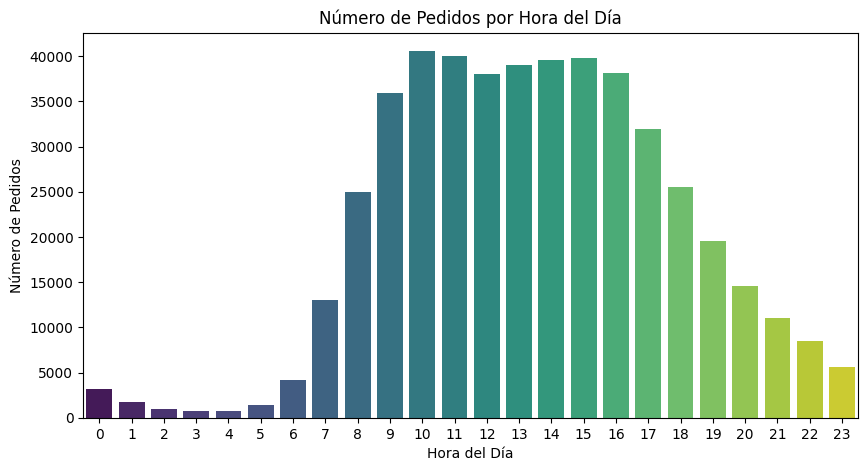

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contar la cantidad de pedidos por hora del día
orders_per_hour = orders['order_hour_of_day'].value_counts().sort_index()

# Crear gráfico
plt.figure(figsize=(10, 5))
sns.barplot(x=orders_per_hour.index, y=orders_per_hour.values, palette="viridis")
plt.xlabel("Hora del Día")
plt.ylabel("Número de Pedidos")
plt.title("Número de Pedidos por Hora del Día")
plt.xticks(range(0, 24))
plt.show()

Escribe aquí tus conclusiones
- Es posible observar un pico en las horas de la mañana (entre las 6:00 y las 9:00) mostrando que usuarios hacen pedidos antes de comenzar sus actividades.
- DEspués de un pequeño decréscimo hay un aumento en el periódo de la tarde (12:00 - 19:00), lo que sugiere que los usuarios tienden a realizar más pedidos durante esas horas.
- Las últimas horas de la noche (después de las 22:00) muestran una disminución significativa en la cantidad de pedidos. Esto es lógico, ya que es común que las personas hagan menos compras en línea tarde por la noche.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>
Buena manera de presentar los datos
</div>


### [A3] ¿Qué día de la semana compran víveres las personas?

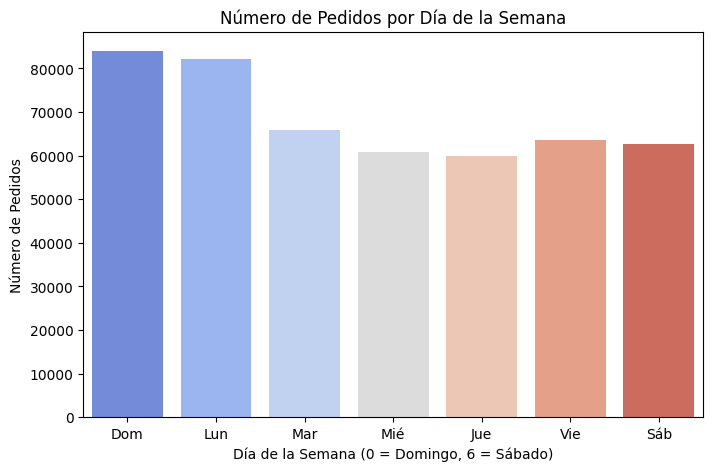

In [43]:
# Contar la cantidad de pedidos por día de la semana
orders_per_dow = orders['order_dow'].value_counts().sort_index()

# Crear gráfico
plt.figure(figsize=(8, 5))
sns.barplot(x=orders_per_dow.index, y=orders_per_dow.values, palette="coolwarm")
plt.xlabel("Día de la Semana (0 = Domingo, 6 = Sábado)")
plt.ylabel("Número de Pedidos")
plt.title("Número de Pedidos por Día de la Semana")
plt.xticks(range(0, 7), ["Dom", "Lun", "Mar", "Mié", "Jue", "Vie", "Sáb"])
plt.show()

Escribe aquí tus conclusiones
- El gráfico muestra que el número de pedidos es relativamente constante de martes a sábado, con una ligera tendencia hacia el aumento a mediados de semana.
- Los domingos y lunes parecen ser los días con mayor cantidad de pedidos. Esto podría reflejar comportamientos de compra más frecuentes devido a la mayor cantidad de tiempo disponible.
- Los miércoles y jueves muestran menor actividad de compras.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!<br/>
Los domingos son los días preferidos de los clientes
</div>


### [A4] ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.

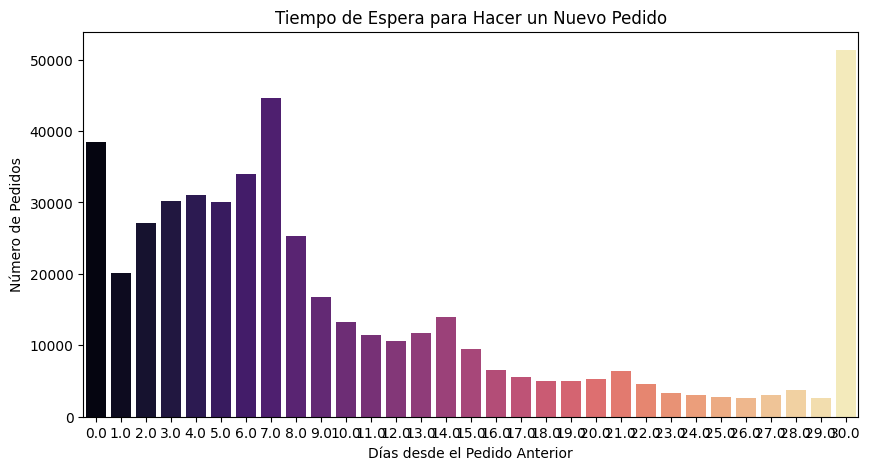

Valor mínimo en 'days_since_prior_order': 0.0
Valor máximo en 'days_since_prior_order': 30.0


In [44]:
# Contar la cantidad de pedidos según el tiempo desde el pedido anterior
days_since_order = orders['days_since_prior_order'].value_counts().sort_index()

# Crear gráfico
plt.figure(figsize=(10, 5))
sns.barplot(x=days_since_order.index, y=days_since_order.values, palette="magma")
plt.xlabel("Días desde el Pedido Anterior")
plt.ylabel("Número de Pedidos")
plt.title("Tiempo de Espera para Hacer un Nuevo Pedido")
plt.show()

# Ver valores mínimos y máximos
print(f"Valor mínimo en 'days_since_prior_order': {orders['days_since_prior_order'].min()}")
print(f"Valor máximo en 'days_since_prior_order': {orders['days_since_prior_order'].max()}")

Escribe aquí tus conclusiones
- Distribución del Tiempo de Espera: La mayoría de los pedidos se realizan en un intervalo corto y parece ocurrir en los primeros 7 días desde el pedido anterior, lo que puede sugerir que los consumidores repiten sus compras con bastante rapidez, especialmente en plataformas como Instacart, que se enfocan en compras de comestibles y productos de consumo frecuente.
- Valor Mínimo (0 días): Indica que algunos clientes realizan pedidos inmediatamente después de haber hecho uno anterior. Esto puede indicar un comportamiento de compra frecuente o la necesidad urgente de productos.
- Valor Máximo (30 días):Indica que hay clientes que toman un mes completo para realizar un nuevo pedido, lo que sugiere que ciertos consumidores compran menos a menudo o prefieren esperar más tiempo entre compras, posiblemente debido a la satisfacción con sus compras previas o a la naturaleza de los productos.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Los resultados son correctos
<br />
Hasta este punto no podemos saber si realmente los usuarios esperan 30 días para realizar otra compra o es el sistema el que agrupa todas las compras que sean mayores a 30 días en el día 30. Con la gráfica podemos observar que la mayoría de usuarios se concentra entre 1 y 9 días donde después los números descienden gradualmente
</div>


# [B] Intermedio (deben completarse todos para aprobar)

1. ¿Existe alguna diferencia entre las distribuciones `'order_hour_of_day'` de los miércoles y los sábados? Traza gráficos de barra de `'order_hour_of_day'` para ambos días en la misma figura y describe las diferencias que observes.
2. Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...).
3. ¿Cuáles son los 20 principales productos que se piden con más frecuencia (muestra su identificación y nombre)?

### [B1] Diferencia entre miércoles y sábados para  `'order_hour_of_day'`. Traza gráficos de barra para los dos días y describe las diferencias que veas.

In [45]:
# Filtrar pedidos de miércoles (order_dow = 3) y sábados (order_dow = 6)
orders_wednesday = orders[orders['order_dow'] == 3]
orders_saturday = orders[orders['order_dow'] == 6]

In [46]:
# Contar pedidos por hora del día
orders_wed_hours = orders_wednesday['order_hour_of_day'].value_counts().sort_index()
orders_sat_hours = orders_saturday['order_hour_of_day'].value_counts().sort_index()

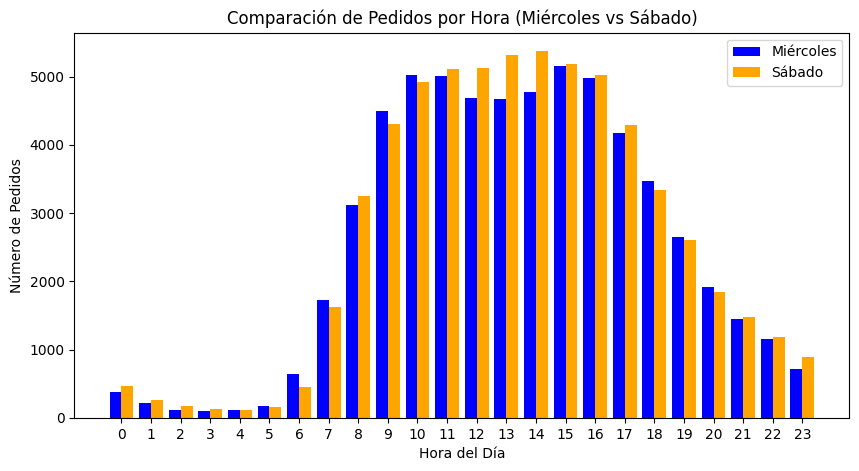

In [47]:
# Graficar
plt.figure(figsize=(10, 5))
plt.bar(orders_wed_hours.index - 0.2, orders_wed_hours.values, width=0.4, label="Miércoles", color="blue")
plt.bar(orders_sat_hours.index + 0.2, orders_sat_hours.values, width=0.4, label="Sábado", color="orange")

plt.xlabel("Hora del Día")
plt.ylabel("Número de Pedidos")
plt.title("Comparación de Pedidos por Hora (Miércoles vs Sábado)")
plt.xticks(range(0, 24))
plt.legend()
plt.show()

Escribe aquí tus conclusiones
- Se observa una distribución general de pedidos por hora para los miércoles y sábados, con diferencias significativas en ciertos horarios.
- Miércoles: Hay picos en las horas de la tarde y noche, especialmente alrededor de las 15:00 a 17:00, lo que sugiere que las personas tienden a hacer pedidos en la tarde.
- Sábado: Los pedidos en Sábado parecen estar más distribuidos a lo largo del día, con un pico temprano por la mañana (entre las 10:00 a 12:00) y en la tarde (12:00-16:00).

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!
<br />
Buena manera de mostrar los resultados de ambos días en una misma grafica
</div>


### [B2] ¿Cuál es la distribución para el número de pedidos por cliente?

In [48]:
# Contar el número de pedidos por cliente
orders_per_user = orders['user_id'].value_counts()

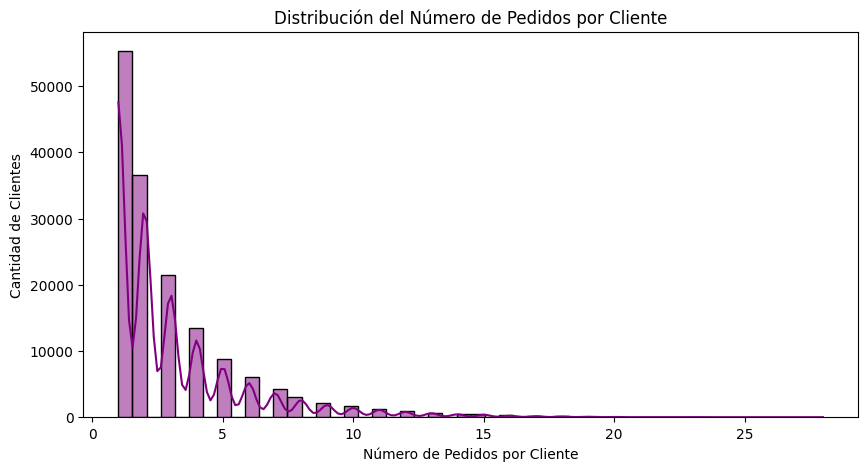

In [49]:
# Graficar la distribución
plt.figure(figsize=(10, 5))
sns.histplot(orders_per_user, bins=50, kde=True, color="purple")
plt.xlabel("Número de Pedidos por Cliente")
plt.ylabel("Cantidad de Clientes")
plt.title("Distribución del Número de Pedidos por Cliente")
plt.show()

Escribe aquí tus conclusiones
- Se puede notar que la mayoría de los clientes han realizado un número relativamente pequeño de pedidos, con una mayor concentración de clientes que han realizado solo 1 o 2 compras. por otro lado, hay algunos clientes que han realizado un número significativo de pedidos, lo que indica que hay ciertos usuarios recurrentes o leales que utilizan la plataforma con más frecuencia.
- La distribución tiene una forma sesgada hacia la izquierda, lo que significa que la mayoría de los clientes hacen pocos pedidos, pero una minoría de clientes realiza la mayoría de los pedidos. 
- La curva de distribución muestra que un número considerable de clientes no realiza compras frecuentes, lo que sugiere que la mayoría de los usuarios son clientes ocasionales. Por otro lado, aquellos clientes con más de 10 pedidos pueden representar a los clientes más leales que compran con regularidad.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!<br/> 

La mayoría de usuarios no ha hecho muchos pedidos, buenas observaciones.

</div>


### [B3] ¿Cuáles son los 20 productos más populares (muestra su ID y nombre)?

In [50]:
# Contar la cantidad de veces que se ha pedido cada producto
product_counts = order_products['product_id'].value_counts().head(20)


In [51]:
# Obtener los nombres de los productos
top_products = products[products['product_id'].isin(product_counts.index)][['product_id', 'product_name']]
top_products = top_products.merge(product_counts.rename("order_count"), left_on="product_id", right_index=True)

In [52]:
# Ordenar por número de pedidos
top_products = top_products.sort_values("order_count", ascending=False)
# Mostrar los 20 productos más populares
print(top_products)

       product_id              product_name  order_count
24851       24852                    Banana        66050
13175       13176    Bag of Organic Bananas        53297
21136       21137      Organic Strawberries        37039
21902       21903      Organic Baby Spinach        33971
47208       47209      Organic Hass Avocado        29773
47765       47766           Organic Avocado        24689
47625       47626               Large Lemon        21495
16796       16797              Strawberries        20018
26208       26209                     Limes        19690
27844       27845        Organic Whole Milk        19600
27965       27966       Organic Raspberries        19197
22934       22935      Organic Yellow Onion        15898
24963       24964            Organic Garlic        15292
45006       45007          Organic Zucchini        14584
39274       39275       Organic Blueberries        13879
49682       49683            Cucumber Kirby        13675
28203       28204        Organi

Escribe aquí tus conclusiones
- Los productos más populares están dominados por frutas orgánicas y productos frescos.
- Es probable que estos productos sean populares debido a una demanda creciente por alimentos frescos, naturales y orgánicos, que han ganado popularidad en la alimentación moderna.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Los resultados son correctos!<br/>
Los clientes tienden a comprar productos naturales, buena manera de mostrar los resultados
</div>


# [C] Difícil (deben completarse todos para aprobar)

1. ¿Cuántos artículos suelen comprar las personas en un pedido? ¿Cómo es la distribución?
2. ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?
3. Para cada producto, ¿cuál es la tasa de repetición del pedido (número de repeticiones de pedido/total de pedidos?
4. Para cada cliente, ¿qué proporción de los productos que pidió ya los había pedido? Calcula la tasa de repetición de pedido para cada usuario en lugar de para cada producto.
5. ¿Cuáles son los 20 principales artículos que la gente pone primero en sus carritos (muestra las IDs de los productos, sus nombres, y el número de veces en que fueron el primer artículo en añadirse al carrito)?

### [C1] ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?

In [53]:
# Filtrar solo productos que fueron reordenados
reordered_products = order_products.query("reordered == 1")
reorder_counts = reordered_products.groupby("product_id").size().nlargest(20).reset_index(name="reorder_count")


In [54]:
# Obtener los nombres de los productos
top_reordered_products = reorder_counts.merge(products, how="left", on="product_id")
print(top_reordered_products)


    product_id  reorder_count              product_name  aisle_id  \
0        24852          55763                    Banana        24   
1        13176          44450    Bag of Organic Bananas        24   
2        21137          28639      Organic Strawberries        24   
3        21903          26233      Organic Baby Spinach       123   
4        47209          23629      Organic Hass Avocado        24   
5        47766          18743           Organic Avocado        24   
6        27845          16251        Organic Whole Milk        84   
7        47626          15044               Large Lemon        24   
8        27966          14748       Organic Raspberries       123   
9        16797          13945              Strawberries        24   
10       26209          13327                     Limes        24   
11       22935          11145      Organic Yellow Onion        83   
12       24964          10411            Organic Garlic        83   
13       45007          10076     

In [55]:
# Ordenar por número de reordenaciones
top_reordered_products = top_reordered_products.sort_values("reorder_count", ascending=False)
# Mostrar resultados
print(top_reordered_products)

    product_id  reorder_count              product_name  aisle_id  \
0        24852          55763                    Banana        24   
1        13176          44450    Bag of Organic Bananas        24   
2        21137          28639      Organic Strawberries        24   
3        21903          26233      Organic Baby Spinach       123   
4        47209          23629      Organic Hass Avocado        24   
5        47766          18743           Organic Avocado        24   
6        27845          16251        Organic Whole Milk        84   
7        47626          15044               Large Lemon        24   
8        27966          14748       Organic Raspberries       123   
9        16797          13945              Strawberries        24   
10       26209          13327                     Limes        24   
11       22935          11145      Organic Yellow Onion        83   
12       24964          10411            Organic Garlic        83   
13       45007          10076     

Escribe aquí tus conclusiones
- Productos como Banana y Bag of Organic Bananas, tienen un alto número de reordenaciones, lo que sugiere que los clientes no solo compran estos productos una vez, sino que tienden a volver a comprarlos a lo largo del tiempo.Probablemente esto se deba a que forman parte de la canasta básica de los consumidores.
- El número de reordenaciones y la alta frecuencia de productos como los plátanos indican que la mayoría de los clientes compran entre 1 y 10 artículos en cada pedido, con un énfasis en productos básicos o populares.
- La distribución podría mostrar una asimetría hacia pedidos con pocos productos, ya que muchas personas compran solo unos pocos artículos básicos o de alta demanda en cada pedido. 

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Cuidado!<br/> 

Aqui estas respondiendo la pregunta de la siguiente parte, ete dejo un ejemplo de como resolver este ejercicio:
</div>


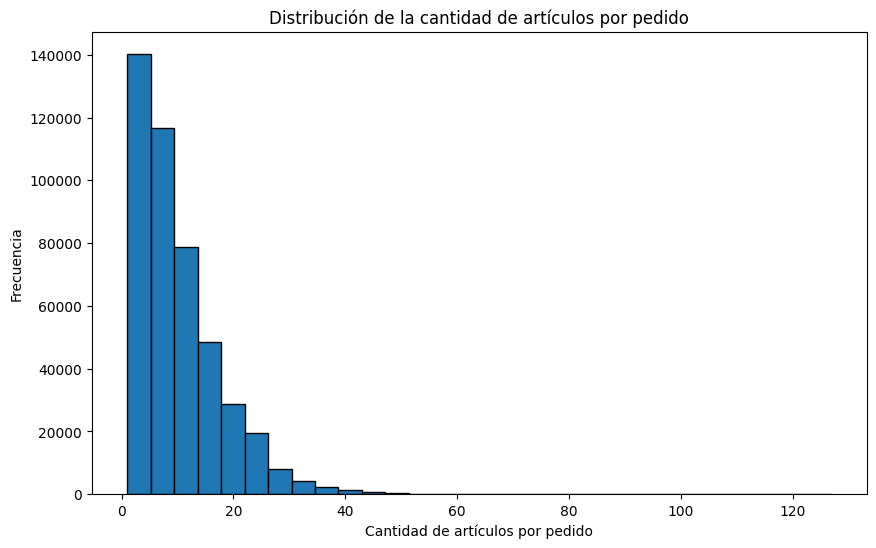

In [69]:
order_counts = order_products.groupby('order_id')['product_id'].count()
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(order_counts, bins=30, edgecolor='black')
plt.xlabel('Cantidad de artículos por pedido')
plt.ylabel('Frecuencia')
plt.title('Distribución de la cantidad de artículos por pedido')
plt.show()

### [C2] ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?

In [56]:
# Filtrar solo productos que fueron reordenados
reordered_products = order_products[order_products["reordered"] == 1]
     # Contar la frecuencia de reordenamientos y obtener los 20 más frecuentes
reordered_counts = reordered_products.groupby("product_id").size().nlargest(20).reset_index(name="reorder_count")

In [57]:
# Obtener los nombres de los productos
top_reordered_products = reordered_counts.merge(products, how="left", on="product_id")

In [58]:
# Ordenar por número de reordenaciones
top_reordered_products = top_reordered_products.sort_values("reorder_count", ascending=False)

In [59]:
# Mostrar resultados
print(top_reordered_products)

    product_id  reorder_count              product_name  aisle_id  \
0        24852          55763                    Banana        24   
1        13176          44450    Bag of Organic Bananas        24   
2        21137          28639      Organic Strawberries        24   
3        21903          26233      Organic Baby Spinach       123   
4        47209          23629      Organic Hass Avocado        24   
5        47766          18743           Organic Avocado        24   
6        27845          16251        Organic Whole Milk        84   
7        47626          15044               Large Lemon        24   
8        27966          14748       Organic Raspberries       123   
9        16797          13945              Strawberries        24   
10       26209          13327                     Limes        24   
11       22935          11145      Organic Yellow Onion        83   
12       24964          10411            Organic Garlic        83   
13       45007          10076     

Conclusiones
- Los productos más reordenados son frutas y vegetales. Esto sugiere que los consumidores tienen una preferencia por productos frescos y orgánicos, como plátanos, aguacates, fresas, y espinacas.
- El consumo recurrente como los plátanos orgánicos y los aguacates, probablemente sean esenciales en la dieta de los consumidores lo que genera una necesidad de reordenarlos regularmente.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!<br/> 
Buena manera de mostrar los resultados, los productos naturales son consistentemente los más vendidos
</div>


### [C3] Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir?

In [60]:
# Calcular tasa de repetición por producto
product_reorder_rate = order_products.groupby("product_id")["reordered"].mean().reset_index()
product_reorder_rate.columns = ["product_id", "reorder_rate"]

In [61]:
# Unir con los nombres de los productos
product_reorder_rate = product_reorder_rate.merge(products, on="product_id")

In [62]:
# Mostrar los productos con la tasa de reordenación más alta
print(product_reorder_rate.sort_values("reorder_rate", ascending=False).head(20))

       product_id  reorder_rate  \
13453       14721           1.0   
19195       20949           1.0   
6136         6723           1.0   
6144         6732           1.0   
41319       45088           1.0   
41310       45078           1.0   
19258       21016           1.0   
19248       21005           1.0   
32273       35192           1.0   
32277       35197           1.0   
6211         6810           1.0   
41274       45040           1.0   
41269       45035           1.0   
25120       27373           1.0   
28203       30748           1.0   
41265       45031           1.0   
32224       35137           1.0   
28202       30747           1.0   
32304       35228           1.0   
32305       35229           1.0   

                                            product_name  aisle_id  \
13453                            Bone Strength Take Care       133   
19195                           Vanilla Sandwich Cookies        37   
6136                                    Palmiers- Peti

Escribe aquí tus conclusiones
- Todos los productos listados tienen una tasa de reordenación del 100% (1.0), lo que significa que, en cada ocasión que fueron comprados, estos productos fueron reordenados en una ocasión posterior. Esto podría indicar que estos productos son altamente demandados y una vez que los consumidores los prueban, tienden a volver a comprarlos.
- Los productos más reordenados incluyen una variedad de artículos, desde alimentos como galletas y helados, hasta productos de cuidado personal y artículos para el hogar. Esto refleja que la tasa de reordenación no está limitada a un solo tipo de producto, sino que abarca varias categorías.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!<br/>
Buena manera de realizar las proporciones
</div>


### [C4] Para cada cliente, ¿qué proporción de sus productos ya los había pedido?

In [63]:
# Calcular la tasa de repetición por usuario
user_reorder_rate = order_products.groupby("order_id")["reordered"].mean().reset_index()
user_reorder_rate.columns = ["order_id", "user_reorder_rate"]
# Unir con la información de los pedidos
user_reorder_rate = user_reorder_rate.merge(orders[["order_id", "user_id"]], on="order_id")


In [64]:
# Calcular la tasa promedio de repetición por usuario
user_avg_reorder_rate = user_reorder_rate.groupby("user_id")["user_reorder_rate"].mean().reset_index()
# Mostrar resultados
print(user_avg_reorder_rate.head(20))

    user_id  user_reorder_rate
0         2           0.038462
1         4           0.000000
2         5           0.666667
3         6           0.000000
4         7           0.944444
5        11           0.200000
6        12           0.250000
7        13           0.481481
8        14           0.451587
9        15           0.633333
10       16           0.549663
11       17           0.714896
12       19           0.523810
13       20           0.000000
14       21           0.464286
15       22           1.000000
16       24           0.500000
17       26           0.516667
18       27           0.635616
19       28           0.444322


Escribe aquí tus conclusiones
- La tasa de reordenación varía ampliamente entre los usuarios. Algunos usuarios tienen tasas de reordenación muy bajas, como el usuario 4 (tasa de reordenación 0.0), lo que sugiere que nunca han vuelto a pedir productos. En contraste, hay usuarios como el usuario 22, que tiene una tasa de reordenación del 100% (1.0), o ususario 7 (0,94), lo que indica que todos los productos que ha pedido los ha vuelto a pedir mostrando que son leales.

### [C5] ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?

In [65]:
# Filtrar los productos que fueron añadidos en primer lugar al carrito
first_added_counts = (
    order_products.query("add_to_cart_order == 1")
    .groupby("product_id")
    .size()
    .reset_index(name="first_added_count")
    .nlargest(20, "first_added_count")
)

In [66]:
# Obtener los nombres de los productos
top_first_added = first_added_counts.merge(products, how="left", on="product_id")

In [67]:
# Ordenar por número de veces que fueron el primer producto agregado
top_first_added = top_first_added.sort_values(by="first_added_count", ascending=False)

# Mostrar resultados
print(top_first_added[["product_id", "product_name", "first_added_count"]])

    product_id                 product_name  first_added_count
0        24852                       Banana              15562
1        13176       Bag of Organic Bananas              11026
2        27845           Organic Whole Milk               4363
3        21137         Organic Strawberries               3946
4        47209         Organic Hass Avocado               3390
5        21903         Organic Baby Spinach               3336
6        47766              Organic Avocado               3044
7        19660                 Spring Water               2336
8        16797                 Strawberries               2308
9        27966          Organic Raspberries               2024
10       44632   Sparkling Water Grapefruit               1914
11       49235          Organic Half & Half               1797
12       47626                  Large Lemon               1737
13         196                         Soda               1733
14       38689     Organic Reduced Fat Milk            

Escribe aquí tus conclusiones
- Los productos más agregados primero a los carritos tienden a ser básicos y comunes en la dieta diaria, como bananas, leche, aguacates y frutas como fresas y frambuesas. Esto refleja que los consumidores probablemente inician sus compras con los productos de uso frecuente o aquellos que forman la base de su compra.
- Muchos de los productos más frecuentes son de origen orgánico, como las bananas orgánicas, el aguacate orgánico y la espinaca orgánica. Esto sugiere que los compradores priorizan alimentos frescos y saludables al comenzar sus compras.
- Adicionalmente, en la lista también hay varios tipos de agua y bebidas como agua con gas y agua mineral. Esto indica que los consumidores, al igual que con los alimentos frescos, consideran los líquidos esenciales y a menudo los añaden rápidamente al carrito.
- Finalmente, los productos son los de uso diario y repetitivo. 


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!<br/>
Una vez más los productos orgánicos estan en el top de la lista<br/>
</div>


### Conclusion general del proyecto:

Comportamiento de los clientes:
Este análisis sobre el comportamiento de los clientes revela patrones clave en sus hábitos de compra. 
Frecuencia de Compra y lealtad: 
- La mayoría de los clientes realizan un número relativamente pequeño de pedidos. Sin embargo, algunos
clientes hacen pedidos más frecuentes, lo que indica la existencia de un grupo de clientes fieles que compran regularmente. 
- Existe una clara tendencia de reordenamiento de productos, especialmente de alimentos básicos y frescos como bananas,
aguacates y leche. Esto indica que muchos consumidores vuelven a comprar los mismos productos.
Productos Populares y Preferencias:
- Los productos más populares, como bananas, fresas y aguacates, reflejan una preferencia por artículos frescos, orgánicos y
esenciales en las compras que ofrecen opciones saludables y que actualmente estan en auge. 
- Los clientes suelen comenzar sus compras con productos de uso diario como leche, agua y frutas frescas. 
Comportamiento de Reordenamiento:
- Tasa de Reordenamiento por Producto: Los productos con alta tasa de repetición son generalmente aquellos que forman parte 
de las compras recurrentes, como frutas, leche y vegetales. Esto sugiere que los consumidores tienden a reordenar productos
cuando estos se agotan.
- Un segmento importante de productos tiene una tasa de reordenamiento alta (1.0), lo que indica que estos productos no solo
se compran una vez, sino que son parte de un patrón de compras repetidas. 
Proporción de Productos Nuevos vs. Reordenados:
- Los primeros productos añadidos al carrito, se ve que los consumidores priorizan ciertos productos esenciales que ya han 
comprado antes, como frutas y leche. Esto destaca que, a pesar de la tendencia a reordenar, los clientes también están dispuestos
a probar productos nuevos.

# Comentario general del revisor
<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Has realizado un buen trabajo, me doy cuenta de que has aplicado los conocimientos que has adquirido durante el curso, las conclusiones a las que llegaste son buenas y los procedimientos realizados son correctos. Considero que este es un proyecto que se empieza a asemejar más a algún proyecto que te pidan en un trabajo, a partir de análisis de este tipo se pueden diseñar estrategias de marketing específicas para ciertos productos o se pueden optimizar los procesos internos para tener disponibles más rápidamente los productos que se venden más seguido.<br/>
    

Continúa con el buen trabajo y mucho éxito en el siguiente Sprint!
</div>
